240000


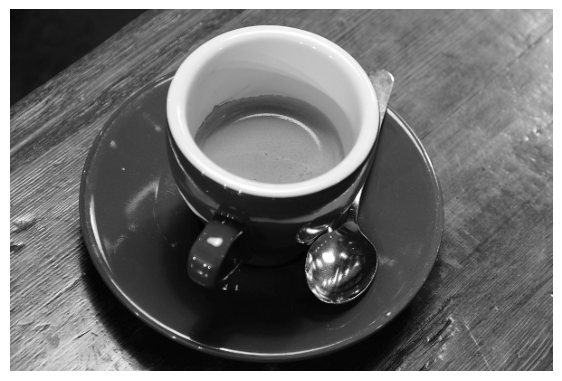

In [1]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from scipy.sparse.linalg import LinearOperator, eigsh
from algorithms import Algorithms
import time

img = sc.rgb2gray( si.data.coffee() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

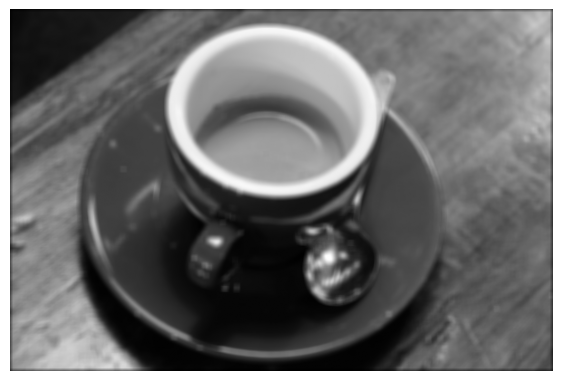

In [3]:
b = A( img )
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

Note que: $f(x) = \frac{1}{2}||Ax - b||_2^2 = \frac{1}{2} x^T (A^TA) x -x^T(A^Tb) + \frac{1}{2}b^Tb$.

<!-- Note que nesse caso, um tamanho de passo que garante a convergência do algoritmo é $\lambda = 1 / L$, onde $L$ é a constante de Lipschitz, que nesse caso é dada por : $||A^T A||_2^2$ -->

No gradiente conjugado, a matriz $Q = A^TA$.



In [4]:
rows, cols = b.shape[ 0 ], b.shape[ 1 ]
dim = rows * cols

def mv( v ):
    x_2d = v.reshape( ( rows, cols ) )
    res_2d = ATA( x_2d )
    return res_2d.reshape( -1 )

operator = LinearOperator( ( dim, dim ), matvec = mv )

eigenvals, _ = eigsh( operator, k = 1, which = 'LM' )

norma_espectral = eigenvals[ 0 ]
print( f"Norma Espectral de A'A: {norma_espectral}" )
print( f'O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de { 1 / norma_espectral }' )

Norma Espectral de A'A: 0.9996470348224453
O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de 1.0003530898059607


In [4]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

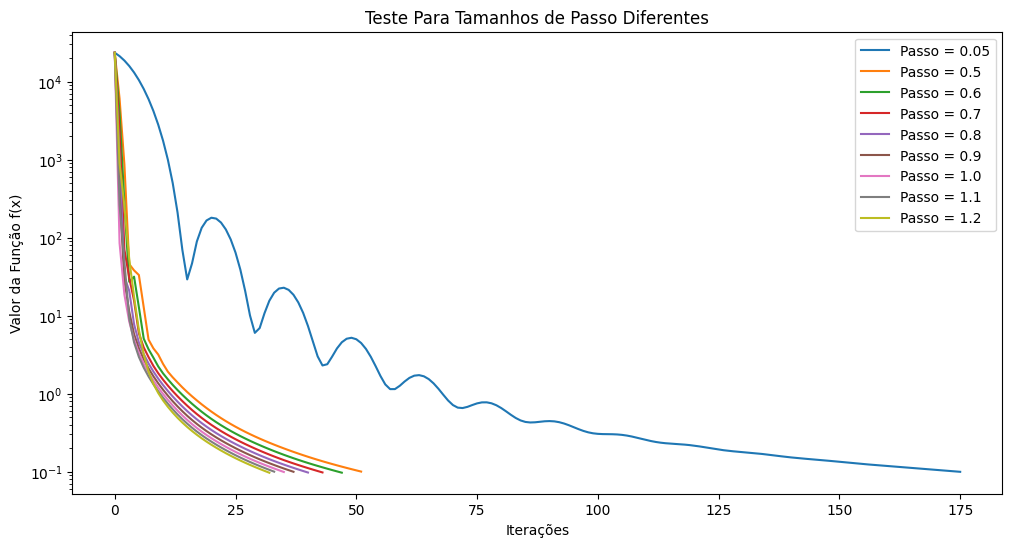

In [5]:
steps = [ 0.05, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2 ]
x = np.zeros_like( img )

lista = []
for step in steps:
    iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = step, tol = 1.0e-1 )
    lista.append( iters_nesterov_fixo )

plt.figure( figsize = ( 12, 6 ) )
for i, step in zip( lista, steps ):
    f_vals_nesterov_fixo = [ f( x ) for x in i ]
    plt.semilogy( f_vals_nesterov_fixo, label = f'Passo = {step}' )
plt.title('Teste Para Tamanhos de Passo Diferentes')
plt.xlabel('Iterações')
plt.ylabel('Valor da Função f(x)')
plt.legend()
plt.show()


Vamos considerar o tamanho de passo $\lambda = 1.0$, veja que é basicamente o ótimo ($\frac{1}{L}$)

In [5]:
x0 = np.zeros_like( img )
x = np.zeros_like( img )

iters_mdbe = Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = 1.0e-1 )

In [6]:
iters_mdpf = Algorithms.mdpf( f, grad_f, x0 = x0, step = 1, tol = 1.0e-1 )

In [7]:
iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = 1, tol = 1.0e-1 )

In [8]:
iters_nesterov_exato = Algorithms.nesterov_exato( f, grad_f, Q = ATA, x = x, tol = 1.0e-1 )

In [9]:
iters_nesterov_backtracking = Algorithms.nesterov_backtracking( f, grad_f, x, step = 1.3, sigma = 1.0e-2, beta = 0.95, tol = 1.0e-1 )

In [10]:
iters_conjugate = Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = 1.0e-1 )


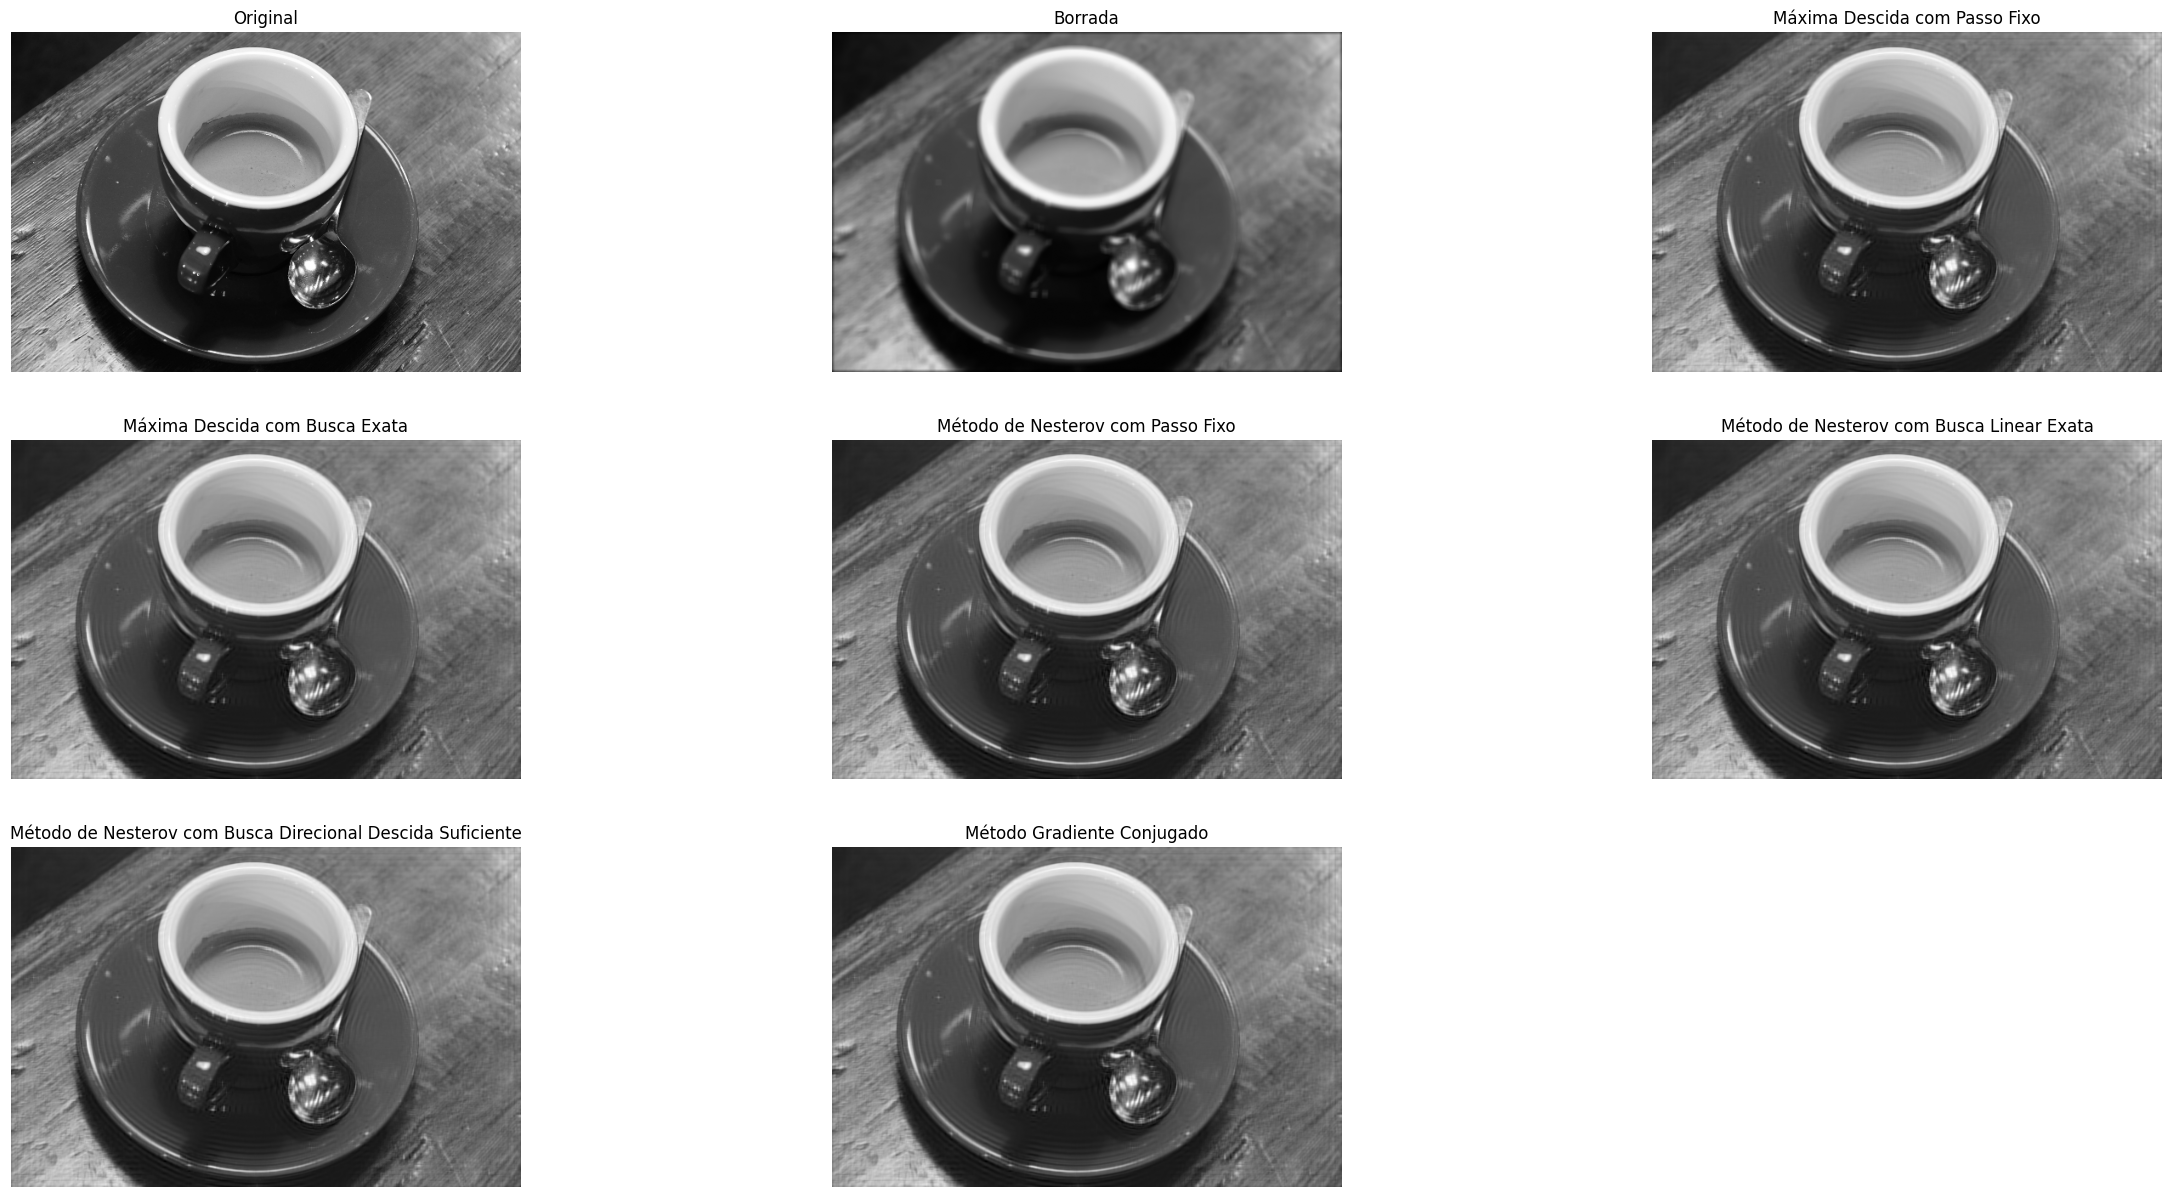

In [11]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 3, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 3, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada" )

plt.subplot( 3, 3, 3 )
plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Passo Fixo" )

plt.subplot( 3, 3, 4 )
plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Busca Exata" )

plt.subplot( 3, 3, 5 )
plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Passo Fixo" )

plt.subplot( 3, 3, 6 )
plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Linear Exata" )

plt.subplot( 3, 3, 7 )
plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

plt.subplot( 3, 3, 8 )
plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método Gradiente Conjugado" )

plt.show()


In [12]:
print( f"O número de iterações do método da máxima descida com busca exata foi de: {len( iters_mdbe )}\n")
print( f"O número de iterações do método da máxima descida com passo fixo foi de: {len( iters_mdpf )}\n")
print( f"O número de iterações do método Nesterov com Passo Fixo foi de: {len( iters_nesterov_fixo )}\n")
print( f"O número de iterações do método Gradiente Conjugado foi de: {len( iters_conjugate )}\n")
print( f"O número de iterações do método Nesterov com Busca Linear Exata foi de: { len( iters_nesterov_exato ) }\n" )
print( f"O número de iterações do método Nesterov com Busca Direcional Descida Suficiente foi de: { len( iters_nesterov_backtracking ) }\n" )

O número de iterações do método da máxima descida com busca exata foi de: 105

O número de iterações do método da máxima descida com passo fixo foi de: 204

O número de iterações do método Nesterov com Passo Fixo foi de: 37

O número de iterações do método Gradiente Conjugado foi de: 18

O número de iterações do método Nesterov com Busca Linear Exata foi de: 32

O número de iterações do método Nesterov com Busca Direcional Descida Suficiente foi de: 33



In [13]:
f_vals_mdbe = [ f( x ) for x in iters_mdbe ]
f_vals_mdpf = [ f( x ) for x in iters_mdpf ]
f_vals_nesterov_fixo = [ f( x ) for x in iters_nesterov_fixo ]
f_vals_conjugate = [ f( x ) for x in iters_conjugate ]
f_vals_nesterov_exato = [ f( x ) for x in iters_nesterov_exato ]
f_vals_nesterov_backtracking = [ f( x ) for x in iters_nesterov_backtracking ]

(np.float64(-10.15),
 np.float64(213.15),
 np.float64(0.05079764039021058),
 np.float64(43747.409265468))

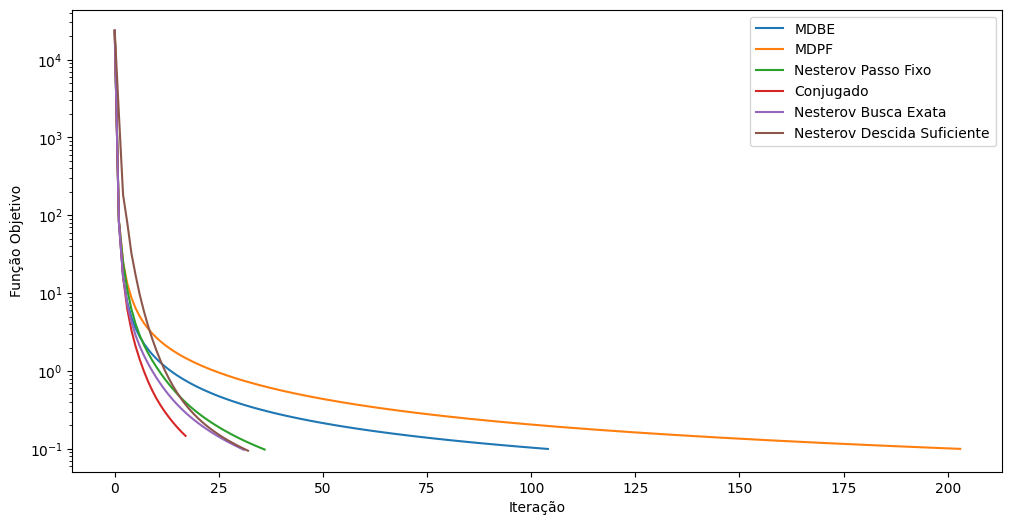

In [14]:
plt.figure( figsize = ( 12, 6 ) )
plt.semilogy( f_vals_mdbe )
plt.semilogy( f_vals_mdpf )
plt.semilogy( f_vals_nesterov_fixo )
plt.semilogy( f_vals_conjugate )
plt.semilogy( f_vals_nesterov_exato )
plt.semilogy( f_vals_nesterov_backtracking )
plt.legend( [ "MDBE", "MDPF", "Nesterov Passo Fixo", "Conjugado", "Nesterov Busca Exata", "Nesterov Descida Suficiente" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Função Objetivo" )
plt.axis( "tight" )

In [5]:
def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000 ):
    results = {}
    for name, method in methods.items():
        print( f"Executando método: {name}" )
        start_time = time.perf_counter()
        iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        values = [ f( x ) for x in iters ]

        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "function_values": values,
            "iters" : iters
        }
        print( f"{name}: {len( iters )} iterações, {exec_time:.4f} segundos." )
    return results

In [6]:
x0 = np.zeros_like( img )
tol = 1e-2
max_iter = 999


In [7]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 1.2, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 849 iterações, 58.1910 segundos.
Executando método: MDPF
MDPF: 1000 iterações, 41.5407 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 109 iterações, 4.6122 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 94 iterações, 6.5679 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 59 iterações, 7.6201 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 99 iterações, 7.1160 segundos.


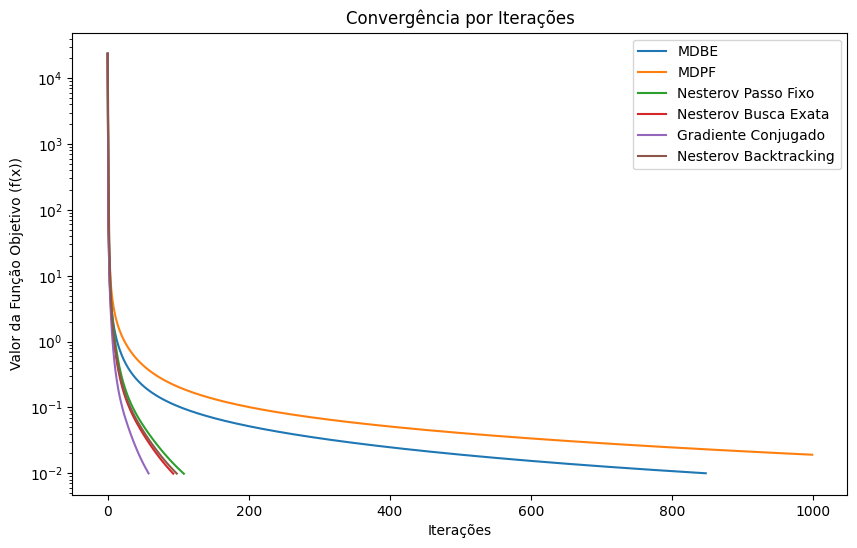

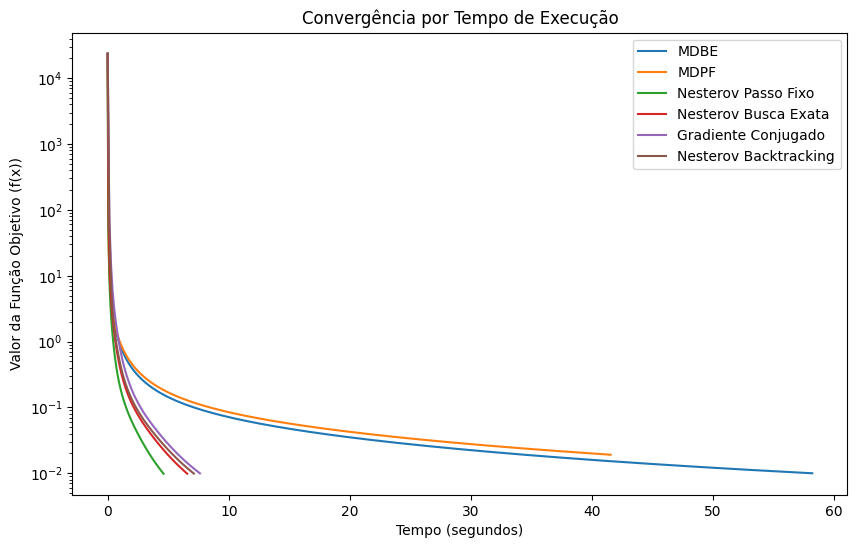

In [8]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


In [1]:
# plt.figure( figsize = ( 30, 15 ) )

# plt.subplot( 3, 3, 1 )
# plt.imshow( img, cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Original" )

# plt.subplot( 3, 3, 2 )
# plt.imshow( b, cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Borrada" )

# plt.subplot( 3, 3, 3 )
# plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Máxima Descida com Passo Fixo" )

# plt.subplot( 3, 3, 4 )
# plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Máxima Descida com Busca Exata" )

# plt.subplot( 3, 3, 5 )
# plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Passo Fixo" )

# plt.subplot( 3, 3, 6 )
# plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Busca Linear Exata" )

# plt.subplot( 3, 3, 7 )
# plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

# plt.subplot( 3, 3, 8 )
# plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método Gradiente Conjugado" )

# plt.show()


In [11]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: MDBE levou a uma avaliação de f(x) igual a 0.00999541012510494
Método: MDPF levou a uma avaliação de f(x) igual a 0.01911725310395164
Método: Nesterov Passo Fixo levou a uma avaliação de f(x) igual a 0.009838661629332855
Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 0.009857701287270154
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 0.009959639336267341
Método: Nesterov Backtracking levou a uma avaliação de f(x) igual a 0.009887289612755536


# Comparando algoritmos por número de iteração


In [9]:
x0 = np.zeros_like( img )
tol = 1e-5
max_iter = 200


In [10]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 1.2, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 201 iterações, 14.6717 segundos.
Executando método: MDPF
MDPF: 201 iterações, 8.3823 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 201 iterações, 8.4626 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 201 iterações, 13.7535 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 201 iterações, 24.6500 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 201 iterações, 14.1762 segundos.


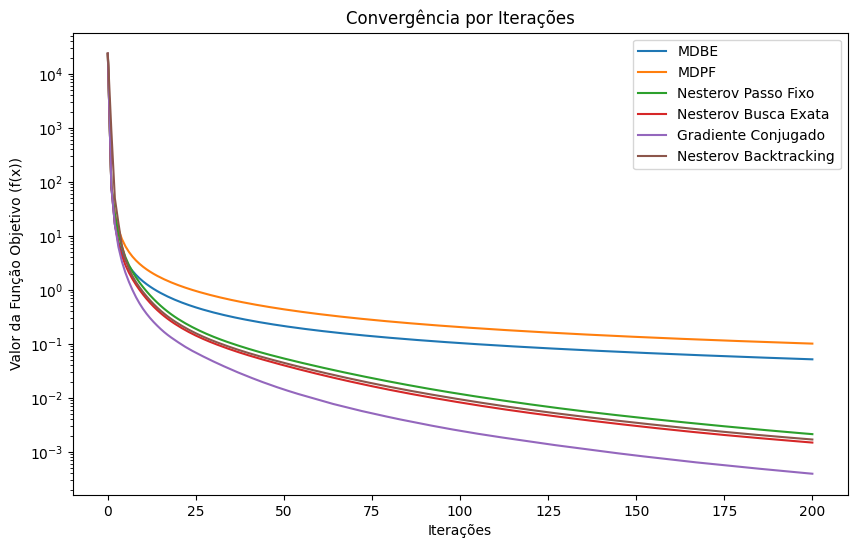

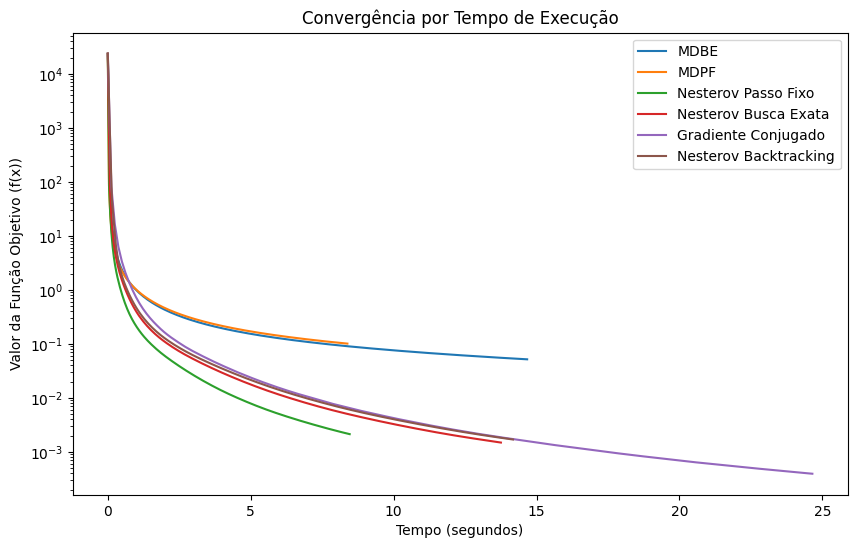

In [11]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


In [13]:
# plt.figure( figsize = ( 30, 15 ) )

# plt.subplot( 3, 3, 1 )
# plt.imshow( img, cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Original" )

# plt.subplot( 3, 3, 2 )
# plt.imshow( b, cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Borrada" )

# plt.subplot( 3, 3, 3 )
# plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Máxima Descida com Passo Fixo" )

# plt.subplot( 3, 3, 4 )
# plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Máxima Descida com Busca Exata" )

# plt.subplot( 3, 3, 5 )
# plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Passo Fixo" )

# plt.subplot( 3, 3, 6 )
# plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Busca Linear Exata" )

# plt.subplot( 3, 3, 7 )
# plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

# plt.subplot( 3, 3, 8 )
# plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
# plt.axis( "off" )
# plt.title( "Método Gradiente Conjugado" )

# plt.show()


In [14]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: MDBE levou a uma avaliação de f(x) igual a 0.05188346844186534
Método: MDPF levou a uma avaliação de f(x) igual a 0.1013500538300591
Método: Nesterov Passo Fixo levou a uma avaliação de f(x) igual a 0.002138504677572656
Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 0.0014936406343793176
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 0.0003959295610390437
Método: Nesterov Backtracking levou a uma avaliação de f(x) igual a 0.001701860295099054


## Experimentos comparando Nesterov busca exata com gradientes conjugados

Usando uma tolerância de $10^{-4}$

In [8]:
x0 = np.zeros_like( img )
tol = 1e-4
max_iter = 1000

In [9]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 562 iterações, 40.3983 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 331 iterações, 40.8975 segundos.


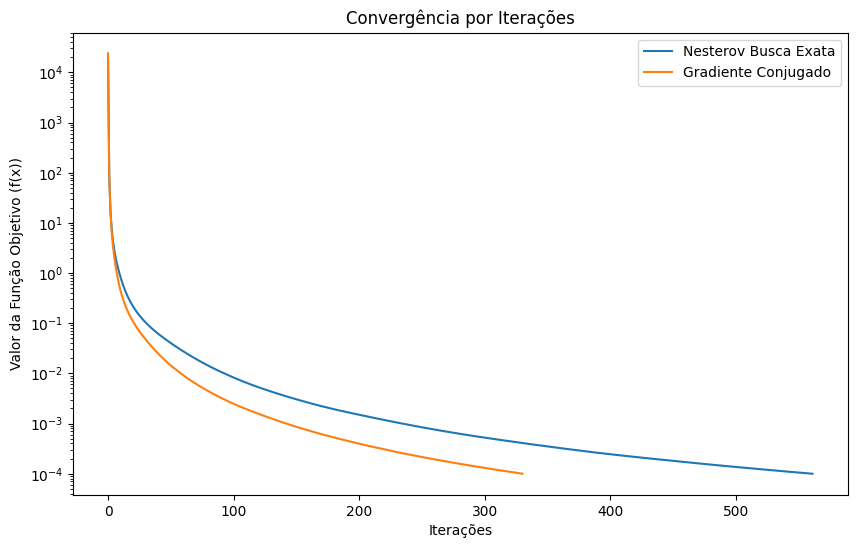

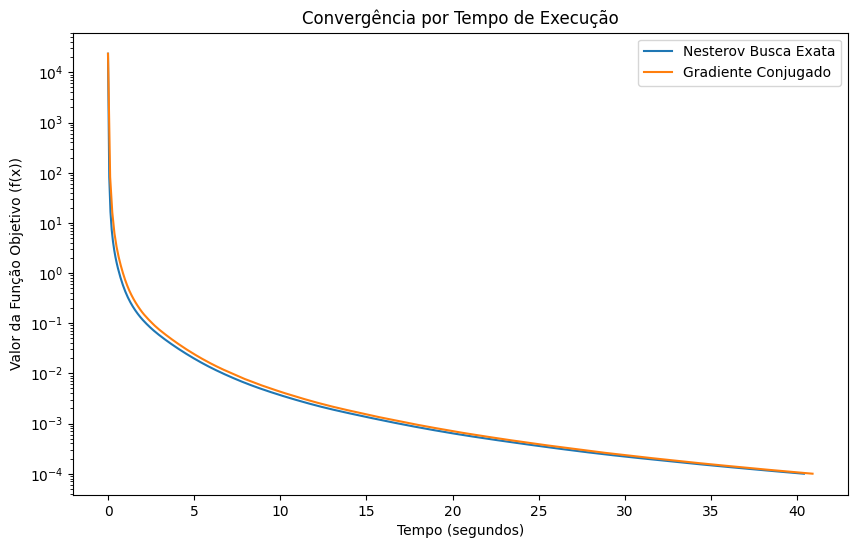

In [10]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


In [11]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 9.979584148221495e-05
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 9.99249428813751e-05


Usando uma tolerância de $10^{-5}$

In [ ]:
x0 = np.zeros_like( img )
tol = 1e-5
max_iter = 1499

In [ ]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 1317 iterações, 92.5665 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 755 iterações, 93.6024 segundos.


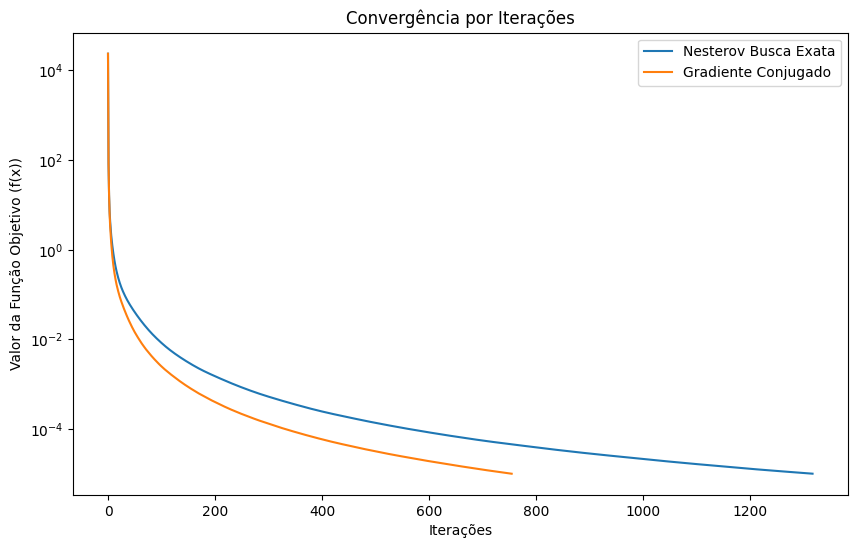

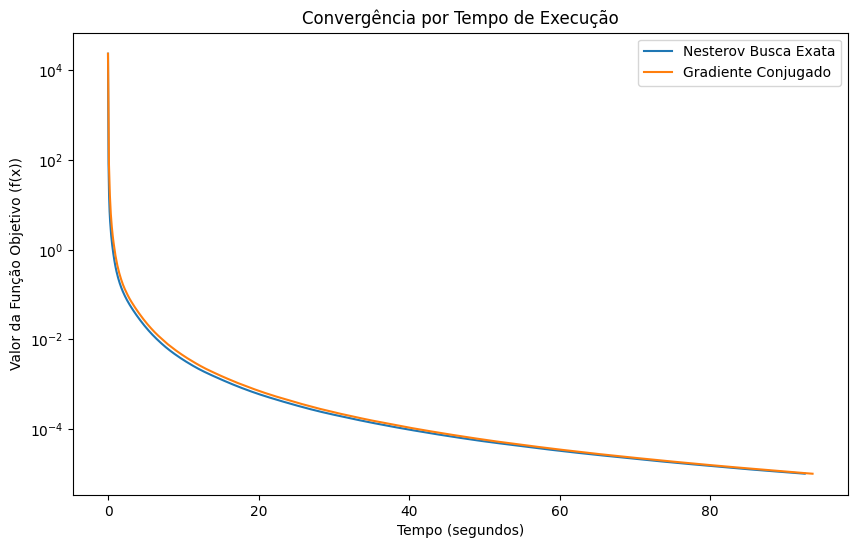

In [8]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


In [ ]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 9.997246177903588e-06
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 9.978343096644179e-06


### Conclusão

Observa-se que o método de Nesterov com busca exata apresenta vantagem em tempo computacional no hardware específico utilizado para os testes. No entanto, o tempo de execução é uma métrica sensível a variações de hardware. Para garantir uma comparação objetiva entre os algoritmos, conforme proposto no plano de trabalho, resolvemos por adotar como métrica a contagem de operações de Produto Matriz-Vetor (PMV).

No problema de mínimos quadrados, verificou-se que ambos os métodos requerem 2 PMVs por iteração. Dado que o custo computacional por iteração é idêntico em termos de operações pesadas, a eficiência do algoritmo é determinada pela quantidade de iterações até convergência. Nos experimentos realizados, temos que em todas as situações o gradiente conjugado convergiu em um menor número de iterações, o que evidencia a superioridade do método.